<a href="https://colab.research.google.com/github/HussamAlabrash/DSA210PROJECT/blob/main/DSA210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importing Libraries

In [13]:
!pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## 2. Data Collection


In [14]:
from google.colab import files
uploaded = files.upload()

## 3. Loading the Data

In [15]:
econ = pd.read_csv("Middle_East_Economic_Data_1990_2024_with_Oil.csv")
conflict = pd.read_csv("MiddleEast_2015-2024_Nov01.csv")

## 4. Data Preparation

The conflict dataset is aggregated to create yearly country-level indicators such as total conflict events and fatalities.

In [16]:
conflict_agg = conflict.groupby(['country', 'year']).agg({
    'event_id_cnty': 'count',
    'fatalities': 'sum'
}).reset_index()

conflict_agg.rename(columns={
    'event_id_cnty': 'conflict_events'
}, inplace=True)

## 5. Filtering Data (2015–2024)

Only overlapping years between datasets are used.

In [17]:
econ_filtered = econ[(econ['Year'] >= 2015) & (econ['Year'] <= 2024)]

## 6. Merging Datasets

The datasets are merged using country and year.

In [18]:
merged = econ_filtered.merge(
    conflict_agg,
    left_on=['Country', 'Year'],
    right_on=['country', 'year'],
    how='left'
)

merged['conflict_events'] = merged['conflict_events'].fillna(0)
merged['fatalities'] = merged['fatalities'].fillna(0)

merged.head()

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel,country,year,conflict_events,fatalities
0,Bahrain,BHR,2015,79.344104,0.199530,3.252330e+10,2.507872,23734.055114,68.571957,1.848627,80.338,1.164,70.0,NaN,NaN,0.0,0.0
1,Bahrain,BHR,2016,70.588291,0.718174,3.388468e+10,3.814993,23800.001441,62.234707,2.786793,80.407,1.190,65.0,Bahrain,2016.0,3165.0,4.0
2,Bahrain,BHR,2017,72.253862,3.833009,3.720481e+10,4.953835,24784.769351,64.175378,1.386718,80.407,1.180,60.0,Bahrain,2017.0,3758.0,18.0
3,Bahrain,BHR,2018,75.715373,4.180793,3.956798e+10,2.052589,26324.406655,68.360000,2.087669,80.412,1.188,55.0,Bahrain,2018.0,1634.0,0.0
4,Bahrain,BHR,2019,73.094424,2.328380,4.044681e+10,2.052878,27259.743860,62.323119,1.005820,80.471,1.217,50.0,Bahrain,2019.0,717.0,1.0


### Conflict Events vs GDP Growth

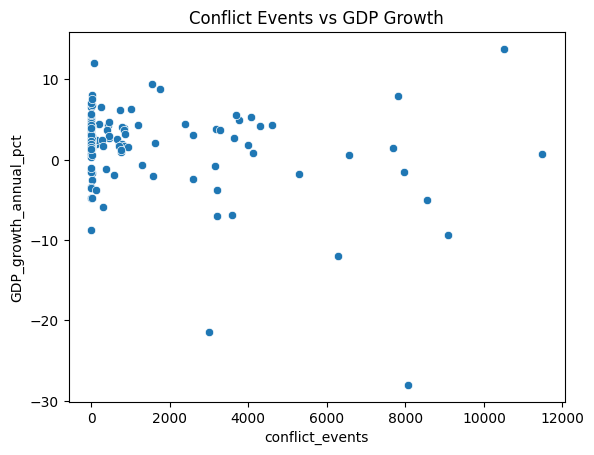

In [19]:
plt.figure()
sns.scatterplot(data=merged, x='conflict_events', y='GDP_growth_annual_pct')
plt.title("Conflict Events vs GDP Growth")
plt.show()

### Fatalities vs Inflation

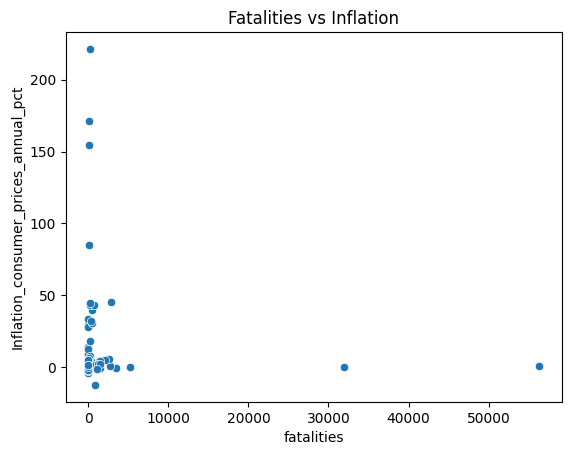

In [20]:
plt.figure()
sns.scatterplot(data=merged, x='fatalities', y='Inflation_consumer_prices_annual_pct')
plt.title("Fatalities vs Inflation")
plt.show()

### Oil Price vs GDP Growth

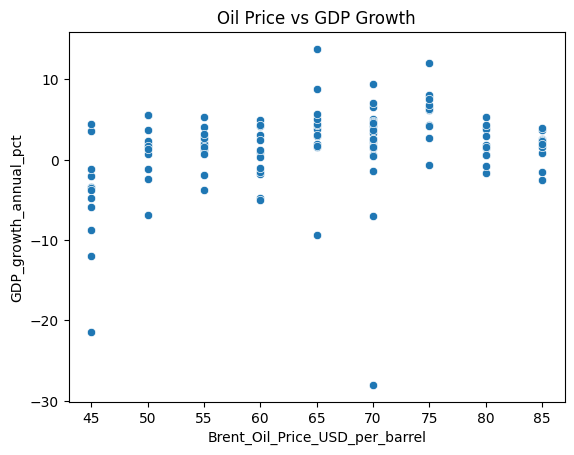

In [21]:
plt.figure()
sns.scatterplot(data=merged, x='Brent_Oil_Price_USD_per_barrel', y='GDP_growth_annual_pct')
plt.title("Oil Price vs GDP Growth")
plt.show()

### Conflict Events Over Time

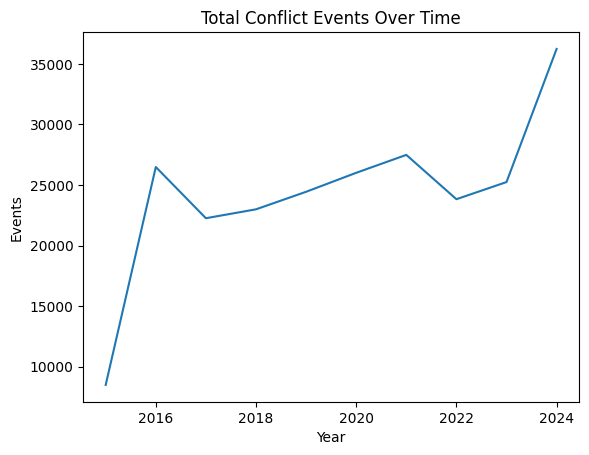

In [22]:
conflict_trend = merged.groupby('Year')['conflict_events'].sum()

plt.figure()
conflict_trend.plot()
plt.title("Total Conflict Events Over Time")
plt.xlabel("Year")
plt.ylabel("Events")
plt.show()

### Hypothesis 1
H₀: Conflict has no effect on GDP growth  
H₁: Conflict negatively affects GDP growth

In [27]:
df = merged[['conflict_events', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.24399904799421807
P-value: 0.006534432771616528


The correlation between conflict events and GDP growth is negative (-0.244), indicating that higher levels of conflict are associated with lower GDP growth. The p-value (0.0065) is less than 0.05, which means the result is statistically significant. Therefore, we reject the null hypothesis and conclude that conflict has a negative effect on GDP growth.

### Hypothesis 2
H₀: Conflict does not affect inflation  
H₁: Conflict increases inflation

In [28]:
df = merged[['fatalities', 'Inflation_consumer_prices_annual_pct']].dropna()

corr, p_value = pearsonr(df['fatalities'], df['Inflation_consumer_prices_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.04134737561611397
P-value: 0.6538726422751064


The correlation between fatalities and inflation is very weak (-0.041), suggesting almost no relationship between the two variables. The p-value (0.6539) is greater than 0.05, indicating that the result is not statistically significant. Therefore, we fail to reject the null hypothesis and conclude that there is no significant relationship between conflict and inflation.

### Hypothesis 3
H₀: Conflict has no effect on FDI  
H₁: Conflict reduces FDI

In [29]:
df = merged[['conflict_events', 'FDI_net_inflows_pct_GDP']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['FDI_net_inflows_pct_GDP'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.38378482552189574
P-value: 1.1763359195311098e-05


The correlation between conflict events and FDI is negative (-0.384), indicating that higher conflict levels are associated with lower foreign direct investment. The p-value (1.18e-05) is much smaller than 0.05, showing strong statistical significance. Therefore, we reject the null hypothesis and conclude that conflict reduces FDI inflows.

### Hypothesis 4
H₀: Oil price has no effect on GDP  
H₁: Oil price affects GDP

In [30]:
df = merged[['Brent_Oil_Price_USD_per_barrel', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['Brent_Oil_Price_USD_per_barrel'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.29928216968072113
P-value: 0.0007717590245511473


The correlation between oil prices and GDP growth is positive (0.299), suggesting that higher oil prices are associated with higher GDP growth. The p-value (0.00077) is less than 0.05, indicating statistical significance. Therefore, we reject the null hypothesis and conclude that oil prices have a significant effect on GDP growth.

## Conclusion

The analysis shows that conflict intensity is negatively associated with GDP growth and negatively associated with FDI inflows. However, no statistically significant relationship was found between conflict and inflation. Oil prices also play a significant role in economic performance, especially in oil-dependent countries. These findings suggest that both political instability and global oil markets are important factors influencing economic outcomes in the Middle East.